# Livrable 1 : Modélisation du Problème d'Optimisation de Tournée de Véhicules avec Contraintes

## Projet CesiCDP - Réponse à l'Appel à Manifestations d'Intérêt ADEME

---

## I. Introduction et Contexte

Depuis les années 1990, les enjeux environnementaux sont au cœur de notre société. En effet, la prise de conscience de la population vis-à-vis du changement climatique s'est traduite par différents accords internationaux (Protocole de Kyoto, 1997 ; Accord de Paris, 2015). Dans ce contexte, l'**ADEME** a lancé un appel visant à améliorer le principe de la **Mobilité Multimodale Intelligente**.

C'est pourquoi notre équipe **CesiCDP** se positionne sur cet appel afin de concevoir un algorithme capable de réduire les temps de parcours, les coûts et l'empreinte carbone liés à la livraison de marchandises. Revenons dans le temps : le problème de tournée de véhicule unique a été formalisé pour la première fois par Dantzig & Ramser sous le nom de **Travelling Salesman Problem (TSP)**, initialement pour la livraison de carburant aux stations-service. Depuis ce jour, il est devenu l'un des problèmes d'optimisation les plus étudiés par les scientifiques.

Aujourd'hui, afin de relever les défis de performance cités précédemment, nous modélisons un **TSP avec fenêtres temporelles (TSPTW)**, possédant deux contraintes principales :

- **Fenêtres temporelles (Time Windows)** : cette contrainte a déjà été étudiée par :
  - Savelsbergh, M.W.P. (1985) – Local Search in Routing Problems with Time Windows, *Annals of Operations Research*.
  - Solomon, M.M. (1987) – Algorithms for the Vehicle Routing and Scheduling Problems with Time Window Constraints, *Operations Research*.

- **Coût ou restriction de passage sur certaines arêtes** : cette contrainte a été étudiée par :
  - George B. Dantzig et John H. Ramser (1959) dans *Management Science*. Dans cet article, ils introduisent la notion de matrice de coûts, représentant les distances à parcourir, ainsi que les contraintes liées à la circulation et à la livraison.

### Organisation du Livrable

Ce document présente :
1. La modélisation formelle du problème (graphe, paramètres, variables, contraintes)
2. La fonction objectif et les contraintes
3. L'analyse de complexité théorique
4. Les méthodes de résolution envisagées


## II. Modélisation Formelle et Mathématique

Nous allons modéliser un problème de livraison avec un **graphe orienté complet**.

En résumé :

| Élément | Représentation |
|---------|----------------|
| **Points** | Villes et clients |
| **Lignes** | Routes |

Nous modélisons le problème avec un **graphe complet**, c'est-à-dire que toutes les villes sont reliées entre elles. Cela signifie que, pour chaque paire de villes $(i,j)$, il existe un chemin possible. Ce choix permet de toujours avoir une solution, car on peut construire une tournée qui passe par toutes les villes. Ensuite, les contraintes (comme les routes bloquées) sont gérées en **ajoutant des pénalités** sous forme de coûts infinis sur les arêtes interdites.

### 2.1 Le Graphe $G = (V, E)$

| Élément | Notation | Description |
|---------|----------|-------------|
| **Sommets** | $V$ | Tous les endroits que le camion doit visiter |
| **Dépôt** | $0$ | Entrepôt (point de départ et d'arrivée) |
| **Clients** | $1$ à $n$ | Ensemble des $n$ clients à visiter |
| **Arêtes** | $E$ | Routes reliant les différents points. Ex : $(1,3)$ = route entre client 1 et client 3 |

### 2.2 Les Paramètres

| Paramètre | Notation | Description |
|-----------|----------|-------------|
| Coût de trajet | $c(i,j)$ | Coût pour aller de $i$ à $j$ (distance, carburant, temps converti en coût) |
| Route bloquée | $c(i,j) = +\infty$ | Si la route est bloquée, le coût vaut l'infini, rendant le trajet impossible |
| Temps de trajet | $t(i,j)$ | Temps nécessaire pour aller de $i$ à $j$. Ex : $t(1,2) = 10$ minutes |
| Fenêtre temporelle | $[a_i, b_i]$ | Intervalle pendant lequel la livraison est autorisée |
| Début autorisé | $a_i$ | Borne inférieure de la fenêtre temporelle |
| Fin autorisée | $b_i$ | Borne supérieure de la fenêtre temporelle |

### 2.3 Variable de Décision $x_{ij}$ (Binaire)

C'est une variable qui prend les valeurs :

$$x_{ij} = \begin{cases} 
1 & \text{si le véhicule passe par l'arête allant de la ville } i \text{ à la ville } j \\
0 & \text{sinon}
\end{cases}$$

### 2.4 Variable $s_i$

C'est le **temps de trajet** du véhicule à la ville $i$ :

$$s_i = \text{temps d'arrivée à la ville } i$$

### 2.5 Fonction Objectif

Minimiser le coût total de la tournée (somme des coûts de tous les arcs empruntés) :

$$\min Z = \sum_{(i,j)} c(i,j) \cdot x_{ij}$$

Pour chaque $(i,j)$, nous ajoutons soit le coût $c(i,j)$, soit $0$, puis nous faisons la somme totale, et nous cherchons par la suite à la minimiser.

### 2.6 Synthèse du Modèle

| Élément | Description |
|---------|-------------|
| **Type de problème** | TSPTW (Traveling Salesperson Problem with Time Windows) |
| **Variables binaires** | $x_{ij}$ pour chaque arc $(i,j)$ |
| **Variables continues** | $s_i$ pour chaque nœud $i$ |
| **Contraintes principales** | Visite unique, continuité, dépôt, fenêtres temporelles, routes bloquées |
| **Objectif** | Minimisation du coût total |

### Illustration Graphique du Modèle

Pour visualiser notre modélisation, voici un exemple de graphe avec :
- Les **fenêtres temporelles** affichées sous chaque nœud
- Les **coûts normaux** des routes en noir
- Les **routes bloquées** (travaux/interdites) en rouge pointillé avec coût $+\infty$

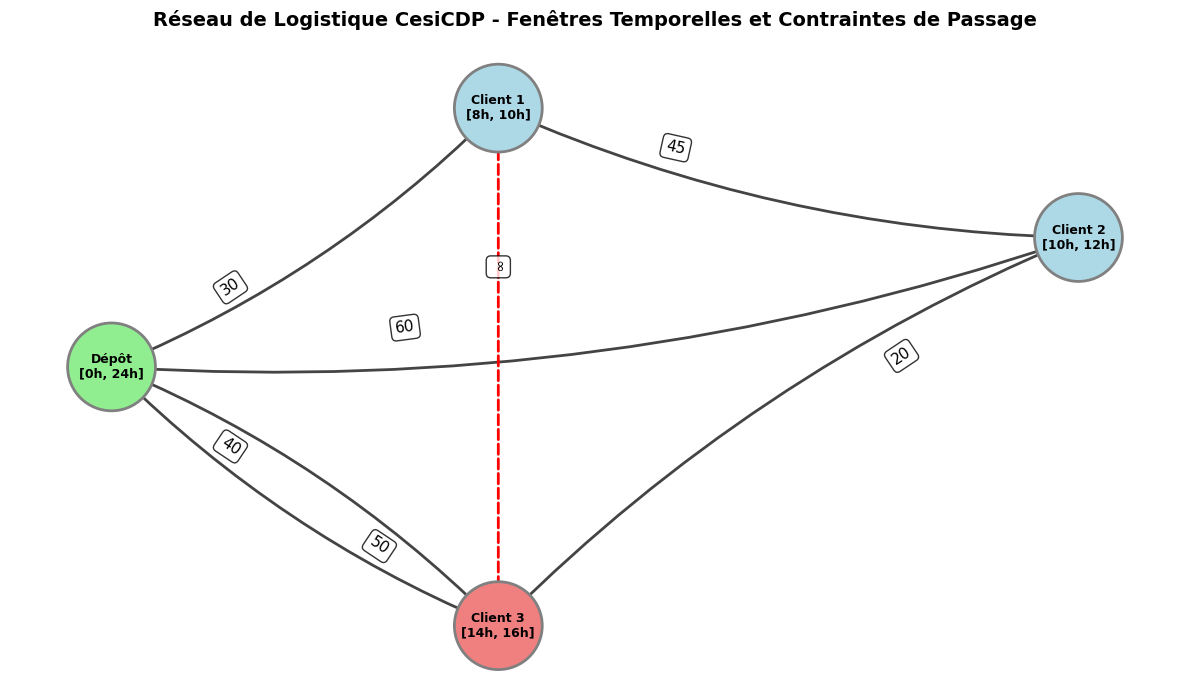

Légende :
  🟢 Dépôt (point de départ/arrivée)
  🔵 Clients avec fenêtres temporelles matinales
  🔴 Client avec fenêtre l'après-midi
  ➖ Route bloquée/interdite (rouge pointillé)


In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Création d'un graphe orienté pour l'exemple
G = nx.DiGraph()

# Définition des nœuds avec positions, labels et fenêtres temporelles
nodes = {
    0: {"pos": (0, 0), "label": "Dépôt\n[0h, 24h]", "color": "lightgreen"},
    1: {"pos": (2, 2), "label": "Client 1\n[8h, 10h]", "color": "lightblue"},
    2: {"pos": (5, 1), "label": "Client 2\n[10h, 12h]", "color": "lightblue"},
    3: {"pos": (2, -2), "label": "Client 3\n[14h, 16h]", "color": "lightcoral"},
}

for n, attr in nodes.items():
    G.add_node(n, pos=attr["pos"], label=attr["label"], color=attr["color"])

# Routes normales avec leurs coûts (temps de trajet en minutes)
normal_edges = [
    (0, 1, 30), (1, 2, 45), (2, 3, 20),
    (3, 0, 50), (0, 3, 40), (0, 2, 60)
]
for u, v, w in normal_edges:
    G.add_edge(u, v, weight=w)

# Route bloquée (travaux) - coût infini
blocked_edge = (1, 3)
G.add_edge(blocked_edge[0], blocked_edge[1], weight=float('inf'))

# Configuration de l'affichage
plt.figure(figsize=(12, 7))
pos = nx.get_node_attributes(G, 'pos')
node_colors = [data["color"] for _, data in G.nodes(data=True)]

# Dessin des nœuds
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, edgecolors="gray", linewidths=2)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'),
                        font_size=9, font_weight="bold")

# Dessin des arêtes normales
nx.draw_networkx_edges(G, pos, edgelist=normal_edges,
                       arrowstyle='->', arrowsize=25,
                       edge_color='#444444', width=2,
                       connectionstyle='arc3,rad=0.1')

# Dessin de la route bloquée
nx.draw_networkx_edges(G, pos, edgelist=[blocked_edge],
                       style='dashed', edge_color='red',
                       arrowstyle='-|>', arrowsize=25, width=2)

# Affichage des poids sur les arêtes
edge_labels = {(u, v): "∞" if d['weight'] == float('inf') else str(d['weight'])
               for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             label_pos=0.3, font_size=11,
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title("Réseau de Logistique CesiCDP - Fenêtres Temporelles et Contraintes de Passage",
          fontsize=14, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Légende :")
print("  🟢 Dépôt (point de départ/arrivée)")
print("  🔵 Clients avec fenêtres temporelles matinales")
print("  🔴 Client avec fenêtre l'après-midi")
print("  ➖ Route bloquée/interdite (rouge pointillé)")

## III. Contraintes du Modèle

### C1 — Visite unique de chaque client

$$\sum_j x_{ij} = 1 \quad \forall i \in \{1, \dots, n\}$$

Cette contrainte assure que chaque client $i$ est visité **exactement une seule fois**, à un seul moment $j$.

### C2 — Continuité du trajet (flux)

$$\sum_j x_{ji} = \sum_j x_{ij} \quad \forall i \in V$$

Cette contrainte garantit que si le véhicule **arrive** à un client $i$, il doit également **repartir** de ce client. Autrement dit, le véhicule ne peut pas s'arrêter chez un client, ce qui évite qu'il reste bloqué à une ville.

### C3 — Départ et retour au dépôt

$$\sum_j x_{0j} \leq 1 \quad \text{et} \quad \sum_i x_{i0} \leq 1$$

Cette contrainte assure que le véhicule **quitte le dépôt au maximum une fois** et **y revient au maximum une fois**. Autrement dit, le véhicule ne peut pas démarrer ou revenir plusieurs fois au dépôt.

### C4 — Respect des fenêtres temporelles

$$a_i \leq s_i \leq b_i \quad \forall i \in V$$

Cette contrainte signifie que nous devons livrer dans le **bon créneau** et aucune livraison n'est autorisée en dehors des horaires spécifiés.

### C5 — Routes interdites

$$x_{ij} = 0 \quad \forall (i,j) \text{ tels que } c(i,j) = +\infty$$

Cette contrainte indique que si une route entre deux clients $i$ et $j$ est bloquée ou inaccessible, le **véhicule ne peut pas l'emprunter**. Nous modélisons cela en ajoutant un coût infini.

### C6 — Domaine des variables

$$x_{ij} \in \{0, 1\} \quad \forall (i,j) \in E$$

$$s_i \geq 0 \quad \forall i \in V$$

---

### Récapitulatif des Contraintes

| Contrainte | Formule | Rôle |
|------------|---------|------|
| **C1** — Visite unique | $\sum_j x_{ij} = 1$ | Chaque client visité exactement une fois |
| **C2** — Continuité | $\sum_j x_{ji} = \sum_j x_{ij}$ | Conservation du flux (entrée = sortie) |
| **C3** — Dépôt | $\sum_j x_{0j} \leq 1$, $\sum_i x_{i0} \leq 1$ | Le véhicule part et revient au dépôt au plus une fois |
| **C4** — Fenêtres temporelles | $a_i \leq s_i \leq b_i$ | Respect des créneaux de livraison |
| **C5** — Routes bloquées | $x_{ij} = 0$ si $c(i,j) = +\infty$ | Interdiction des arêtes bloquées |
| **C6** — Domaine | $x_{ij} \in \{0,1\}$, $s_i \geq 0$ | Intégralité et non-négativité |

## IV. Analyse du Problème et Complexité

### 4.1 Complexité du TSP

Le problème du voyageur de commerce (TSP) consiste à trouver le plus court chemin passant par toutes les villes **exactement une seule fois**. Ce problème est connu pour être **NP-complet**, comme l'a montré Richard M. Karp dans son article *"Reducibility Among Combinatorial Problems"*, publié en 1972 dans l'ouvrage collectif *Complexity of Computer Computations* (édité par Miller & Thatcher, Springer).

| Nombre de villes $n$ | Nombre de tours possibles | Temps estimé (algo exact) |
|----------------------|--------------------------|---------------------------|
| 10 | $\approx 180\,000$ | Millisecondes |
| 20 | $\approx 6 \times 10^{16}$ | Années |
| 50 | $\approx 10^{62}$ | Pas en temps raisonnable |

Malheureusement cette résolution devient très difficile lorsque le nombre de villes est grand. En effet, le nombre de solutions possibles augmente de manière **exponentielle**, ce qui rend les méthodes exactes presque inutilisables pour des instances de taille moyenne ou grande.

### 4.2 Complexité du TSPTW

Dans notre cas, nous travaillons sur le **TSPTW**, permettant d'ajouter des contraintes supplémentaires comme spécifié dans la consigne. Par conséquent, ces contraintes rendent le problème de plus en plus difficile à résoudre. Il ne s'agit maintenant plus seulement de trouver un bon trajet, mais également de **respecter des horaires de manière précise**, ce qui limite fortement le champ des possibles.

Ce problème a notamment été étudié par Marius M. Solomon dans son article *"Algorithms for the Vehicle Routing and Scheduling Problems with Time Window Constraints"*, publié en 1987 dans la revue *Operations Research*.

C'est pourquoi, dans la pratique, on utilise des **méthodes approchées** appelées **heuristiques**, qui permettent de trouver rapidement des solutions satisfaisantes, même si elles ne sont pas toujours optimales.

### 4.3 Formulation Décisionnelle (NP-Complétude)

Nous pouvons formuler notre problème sous forme décisionnelle :

> **Existe-t-il un cycle hamiltonien** respectant les contraintes (fenêtres temporelles et arêtes bloquées) et dont le coût total est inférieur ou égal à un seuil $k$ ?

Ce problème est **NP-complet** car il généralise le problème du cycle hamiltonien, connu pour être NP-complet. En effet, en supprimant les contraintes supplémentaires, on retrouve le problème du TSP.

### 4.4 Complexité et Chaîne de Réduction

Le problème du voyageur de commerce (TSP) est NP-complet. Cela signifie qu'il est difficile à résoudre exactement lorsque le nombre de villes augmente.

On peut relier notre problème à d'autres problèmes connus avec la chaîne de réduction suivante :

$$\text{3-SAT} \leq_p \text{TSP} \leq_p \text{TSPTW}$$

| Étape | Signification |
|-------|---------------|
| **3-SAT** | Problème NP-complet classique |
| **3-SAT → TSP** | Transformation polynomiale possible |
| **TSP → TSPTW** | Le TSPTW est une version plus complexe du TSP (ajout de contraintes temporelles et de routes) |

Ainsi, chaque transformation se fait en **temps polynomial**, donc le TSPTW est **au moins aussi difficile** que le TSP.

## V. Références Bibliographiques

### 6.1 Contexte Environnemental et Institutionnel

1. **Protocole de Kyoto (1997).** Accord international sur la réduction des émissions de gaz à effet de serre.  
   → Premier engagement contraignant à l'échelle internationale.

2. **Accord de Paris (2015).** Accord mondial sur le changement climatique.  
   → Engagement de limiter le réchauffement climatique à 1,5°C.

### 6.2 Articles Fondateurs sur le TSP et le TSPTW

3. **Dantzig, G. B., & Ramser, J. H. (1959).** The truck dispatching problem. *Management Science*, 6(1), 80-91.  
   → Première formalisation du problème de tournée de véhicules avec matrice de coûts.

4. **Karp, R. M. (1972).** Reducibility among combinatorial problems. In *Complexity of Computer Computations* (pp. 85-103). Springer.  
   → Preuve fondatrice de la NP-complétude du TSP.

5. **Savelsbergh, M. W. P. (1985).** Local search in routing problems with time windows. *Annals of Operations Research*, 4(1), 285-305.  
   → Démonstration de la NP-complétude de la faisabilité du TSPTW et algorithmes de recherche locale.

6. **Solomon, M. M. (1987).** Algorithms for the Vehicle Routing and Scheduling Problems with Time Window Constraints. *Operations Research*, 35(2), 254-265.  
   → Référence majeure sur les heuristiques pour le TSPTW.

### 6.3 Méthodes de Résolution

7. **Kirkpatrick, S., Gelatt Jr., C. D. & Vecchi, M. P. (1983).** Optimization by Simulated Annealing. *Science*, Vol. 220, No. 4598, pp. 671–680.  
   → Article fondateur du recuit simulé, appliqué au TSP.

8. **Ohlmann, J. W., & Thomas, B. W. (2007).** A Compressed-Annealing Heuristic for the Traveling Salesman Problem with Time Windows. *INFORMS Journal on Computing*, Vol. 19, No. 1, pp. 80–90.  
   → Version améliorée du recuit simulé adaptée au TSPTW.

---

## VI. Conclusion du Livrable 1

Ce livrable a permis de :

1. **Contextualiser le problème** dans le cadre de la mobilité intelligente et des objectifs environnementaux de l'ADEME
2. **Reformuler le problème** dans un cadre formel (graphe complet, variables $x_{ij}$ et $s_i$, contraintes C1–C6)
3. **Définir la fonction objectif** : minimisation du coût total $\min Z = \sum_{(i,j)} c(i,j) \cdot x_{ij}$
4. **Démontrer la complexité** NP-complète via la chaîne de réduction $\text{3-SAT} \leq_p \text{TSP} \leq_p \text{TSPTW}$